# Raw Data Replication Timing from 10k MNase-seq Windows

April 22, 2024

Compute the replicating timing from the raw MNase-seq 10k windows for each gene.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

# Compute replication profile for each gene

For each gene
1. Compute the raw replication profile
2. Compute its replication time (early/late)
3. Will need to normalize by the replicate's S phase
4. Compute the correlation with its gene expression


In [4]:
mnase_analysis = MNaseOriginAnalysis(replicate=1)

In [5]:
replicate = 1
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

In [6]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

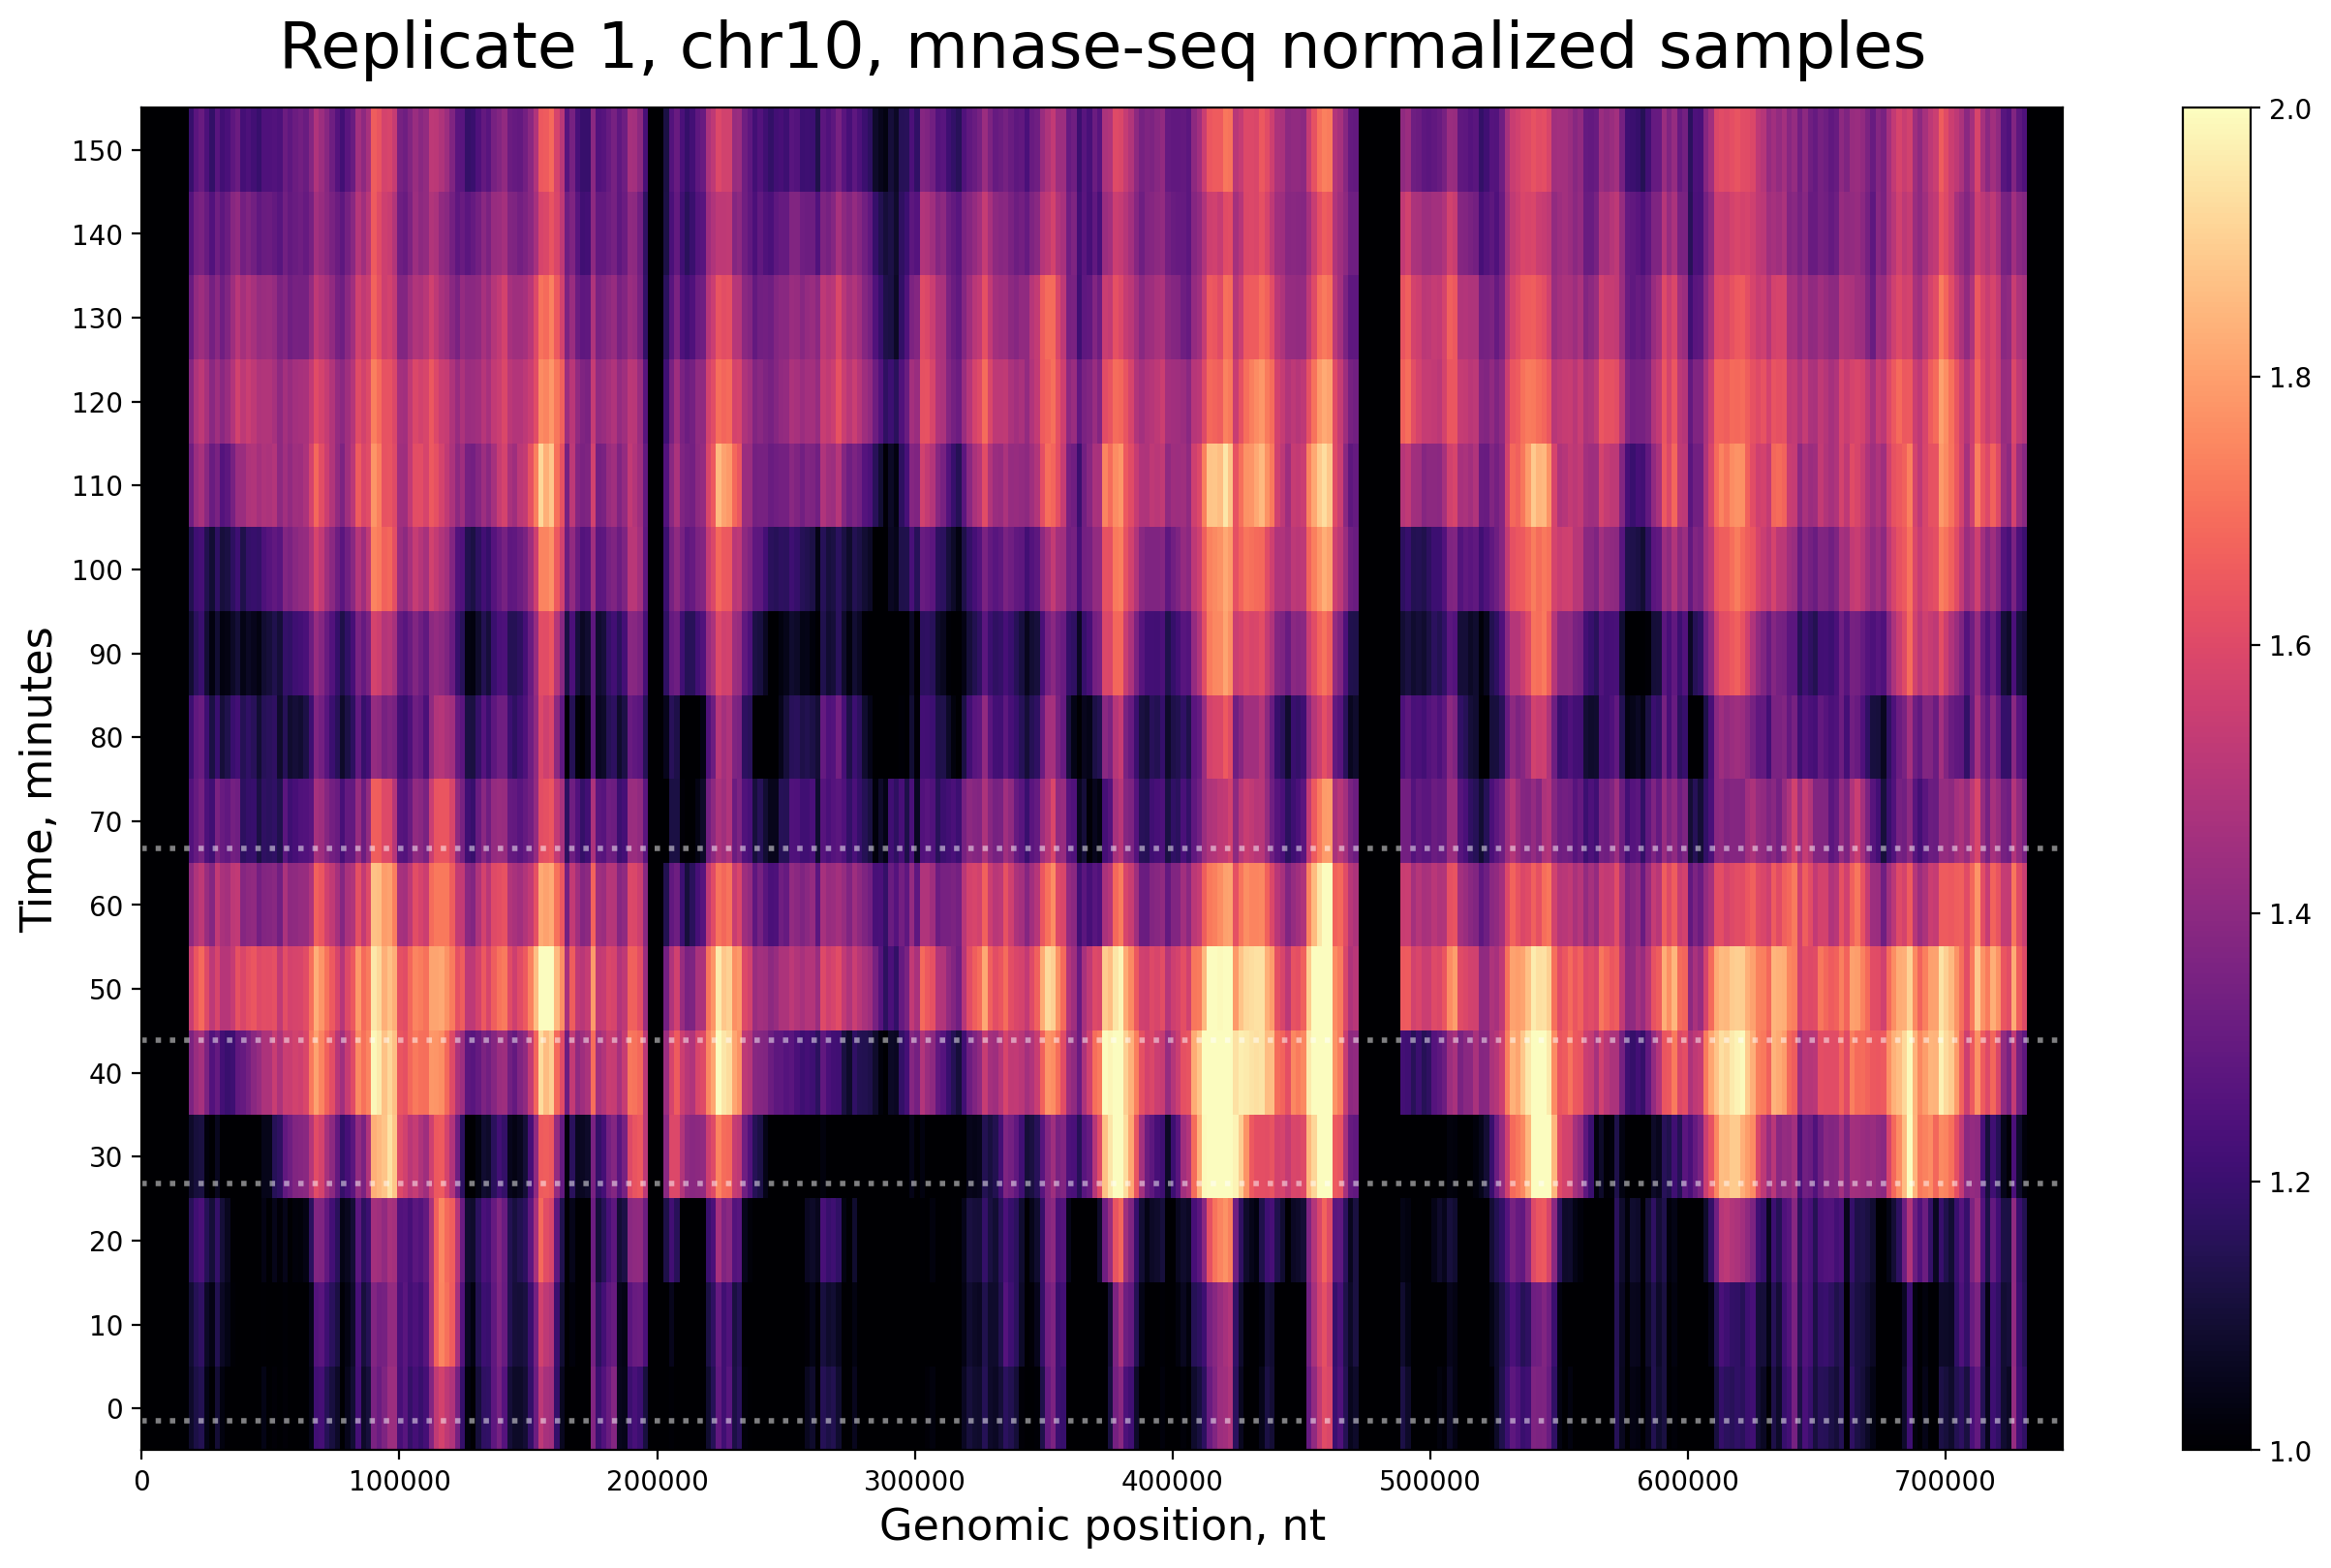

In [7]:
mnase_analysis.plot_heatmap(plot_norm_by_copy=True)

# Compute raw replication timing profile for both replicates

Compute the 10k bin curves for all genes, normalize the occupancy within the first cell cycle length, then compute the time in which the occupancy reaches a specified threshold (currently 75%) for each gene. The time in which this threshold is met is the replication timing.

Perform for both genes, compute the correlation and take the average.


In [8]:
mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves_and_expression_correlations()
mnase_analysis_rep1.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:01.272


In [9]:
mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves_and_expression_correlations()
mnase_analysis_rep2.compute_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:04.878


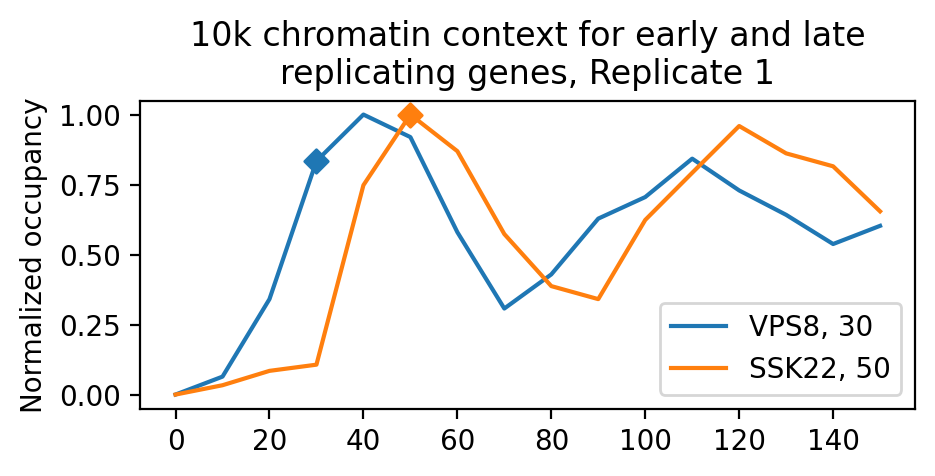

In [10]:
mnase_analysis_rep1.plot_normalized_bin_curves(['VPS8', 'SSK22'])

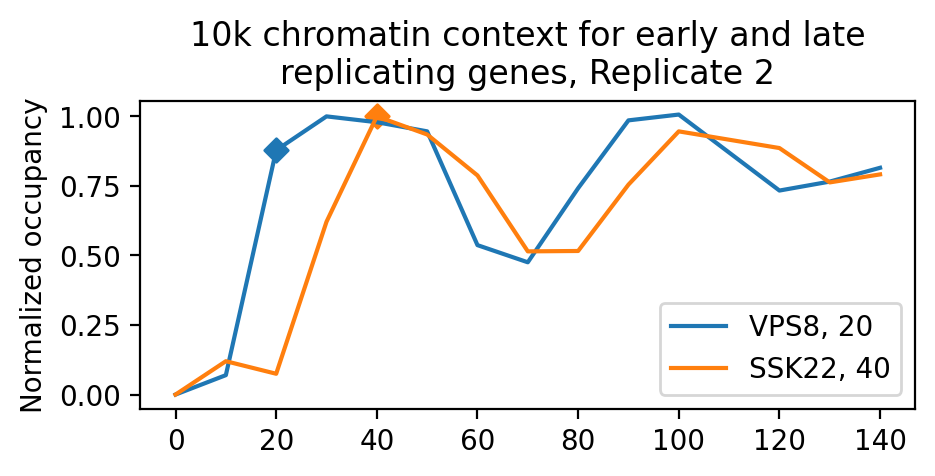

In [11]:
mnase_analysis_rep2.plot_normalized_bin_curves(['VPS8', 'SSK22'])

In [12]:
mnase_analysis_rep1.load_posteriors_for_timing()
mnase_analysis_rep2.load_posteriors_for_timing()

In [13]:
# We have where G1 should start (w/o recovery) and the length of the cell cycle
# so let's normalize based on translating to the that G1 start
# then divide by the cell cycle length

mnase_analysis_rep1.normalize_replication_timing_by_cell_cycle_parameters()
mnase_analysis_rep2.normalize_replication_timing_by_cell_cycle_parameters()

In [37]:
from src.raw_replication_timing import RawReplicationProfileAnalysis

replication_timing_analysis = RawReplicationProfileAnalysis(mnase_analysis_rep1, 
    mnase_analysis_rep2)


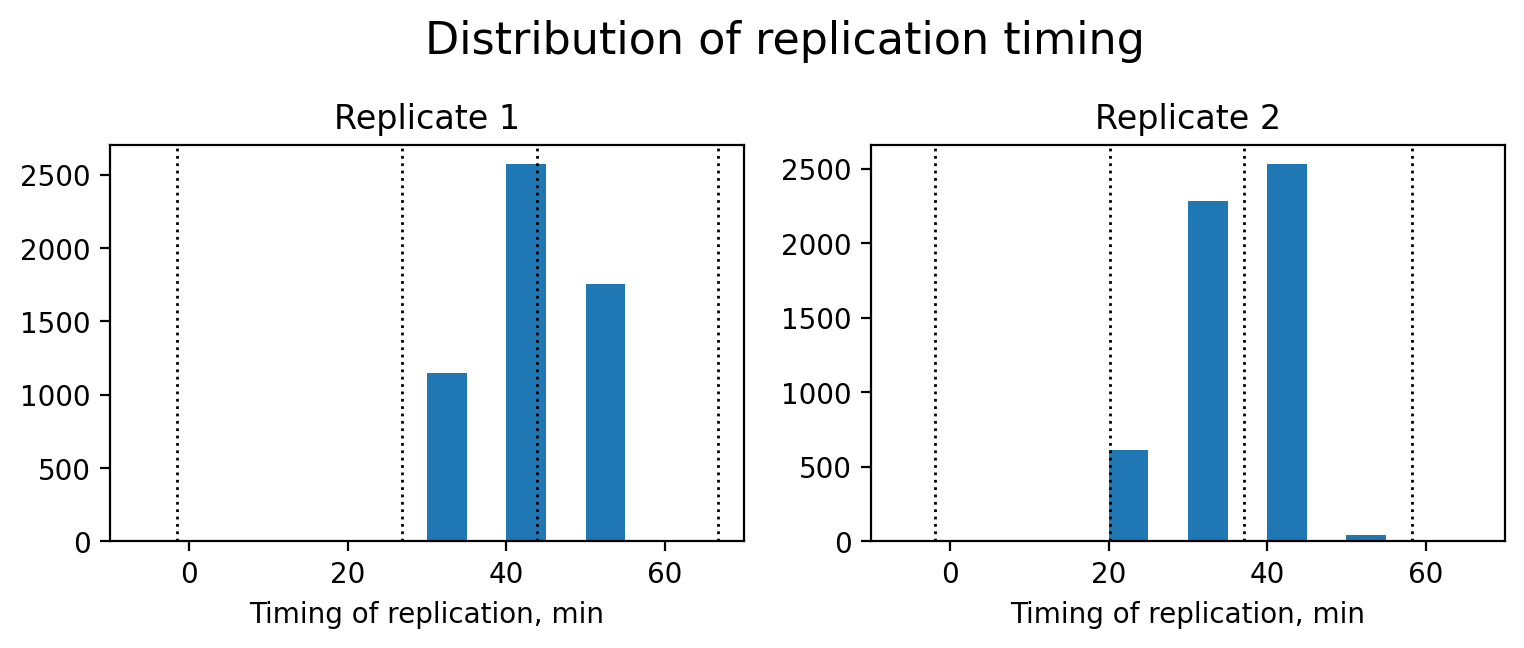

In [38]:
replication_timing_analysis.plot_raw_replication_timing()

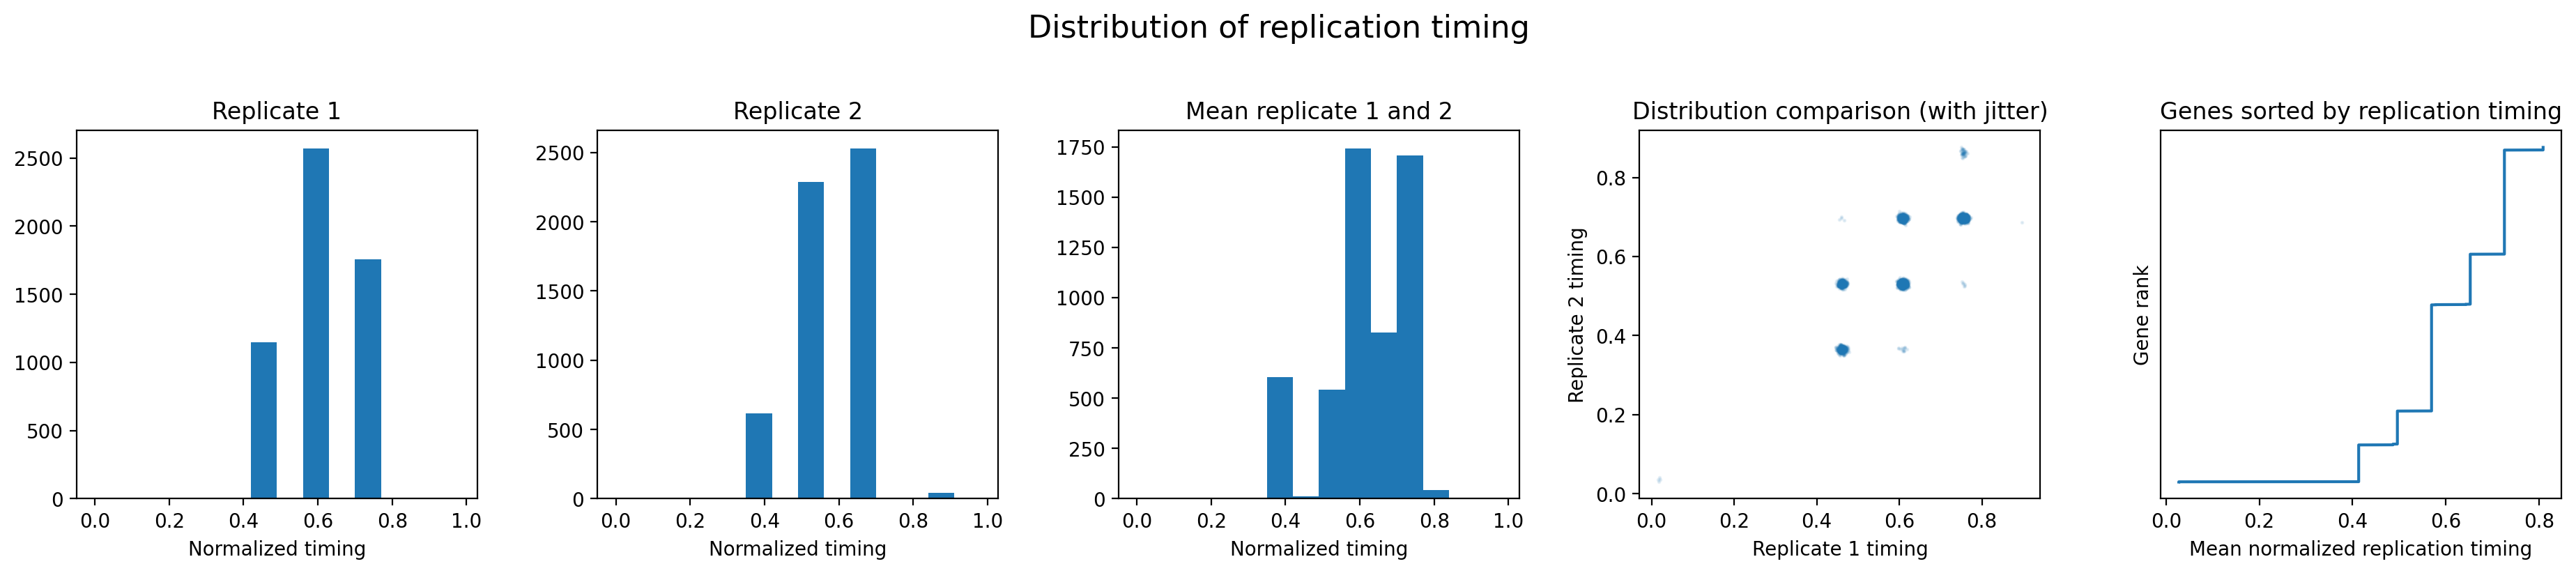

In [39]:
replication_timing_analysis.plot_merged_raw_replication_timing()

In [40]:
replication_timing_analysis.merged_replication_timing.to_csv('datasets/computed_mnase/replication_timing_10k.csv')

In [41]:
# Load the F images, currently we have them ready to plot in the promoter analysis
# but we will move them to its own class

from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
replication_timing_analysis.load_chromatin_images(chromatin_dir)


Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.112
1001/5574 - 00:00:06.836
2001/5574 - 00:00:12.807
3001/5574 - 00:00:18.296
4001/5574 - 00:00:24.788
5001/5574 - 00:00:30.583


In [42]:
replication_timing_analysis.index_f_images_by_repl_timing()

In [43]:
replication_timing_analysis.subset_raw_f_images()

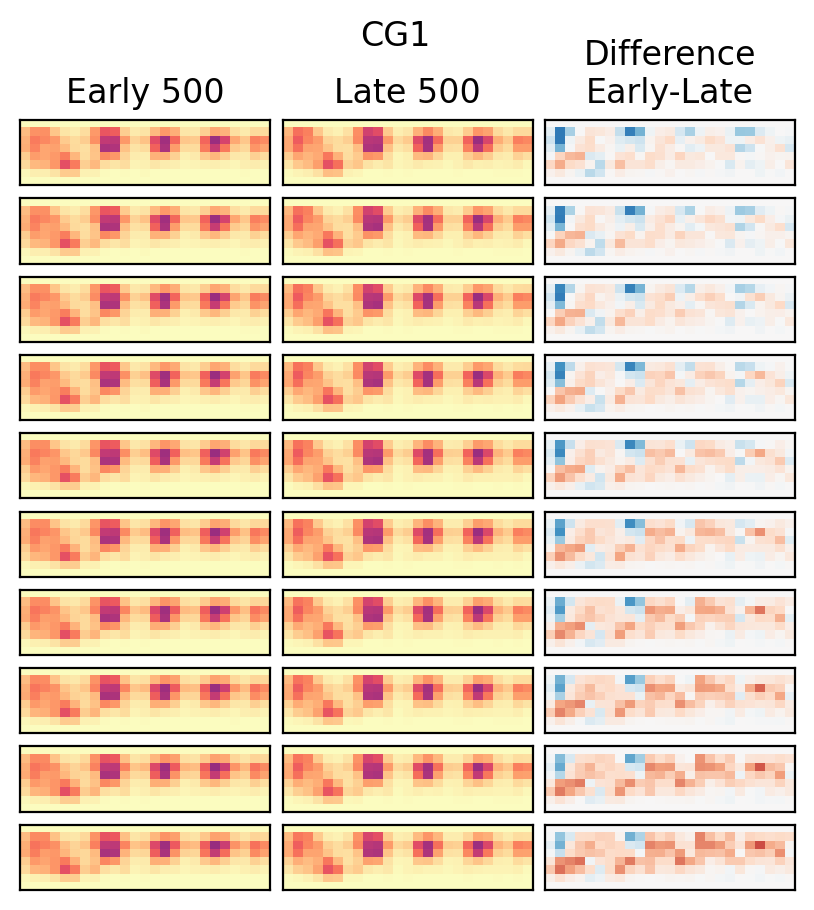

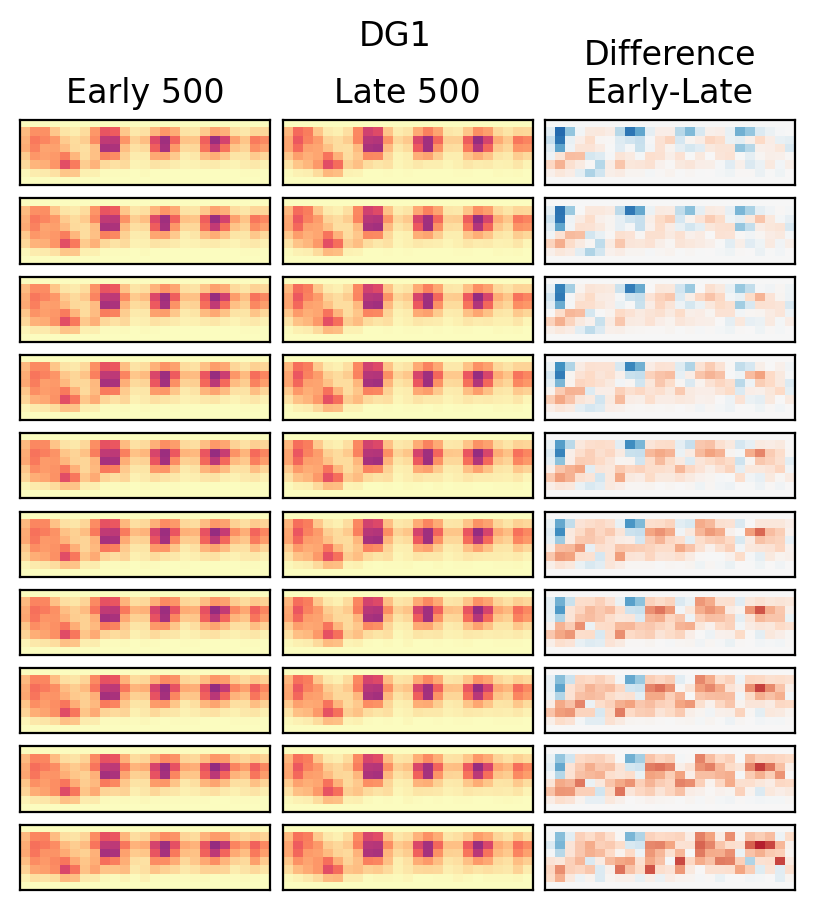

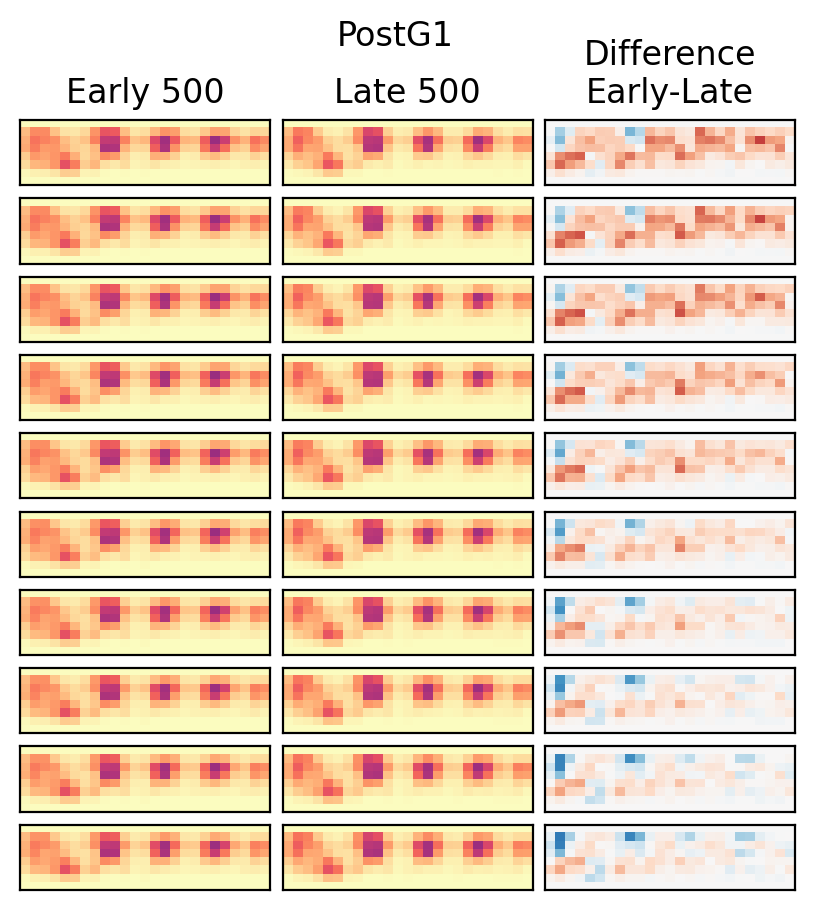

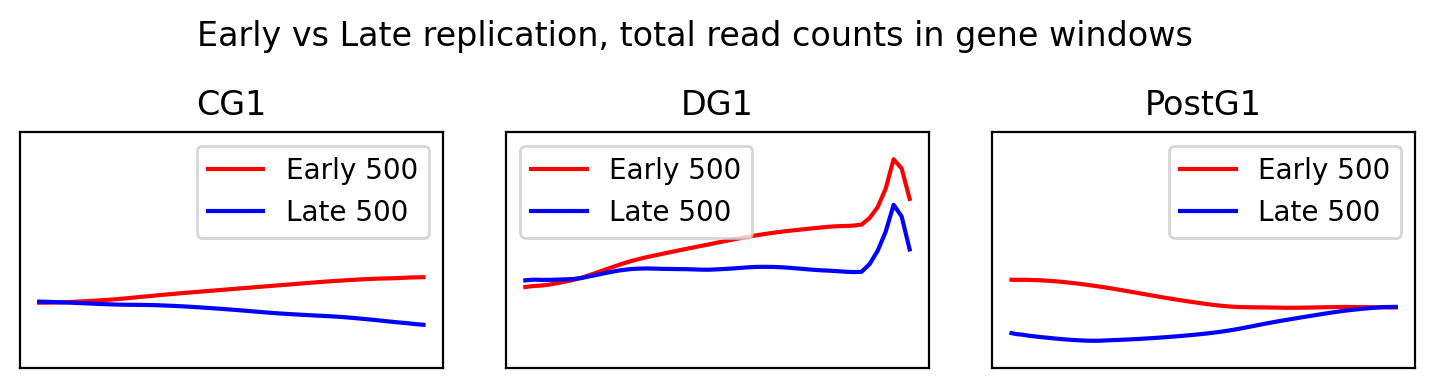

In [44]:
replication_timing_analysis.plot_raw_subsets_replication_timing()